In [47]:
       
from langchain_google_genai import ChatGoogleGenerativeAI

llm=ChatGoogleGenerativeAI(model="gemini-1.5-flash-latest")

In [48]:
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.graph.message import add_messages
from typing import Annotated, Literal, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

In [49]:
def call_model(state:MessagesState):
    messages=state['messages']
    response=llm.invoke(messages)
    return {'messages':[response]}


In [50]:
workflow=StateGraph(MessagesState)
workflow.add_node("chatbot",call_model)
workflow.add_edge(START,"chatbot")
workflow.add_edge("chatbot",END)
app=workflow.compile()

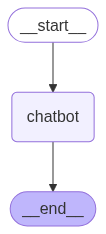

In [51]:
app

In [52]:
input={"messages":["hi my name is abhishek"]}

In [53]:
app.invoke(input)

{'messages': [HumanMessage(content='hi my name is abhishek', additional_kwargs={}, response_metadata={}, id='07594e62-1818-4318-8171-9282bd1f165e'),
  AIMessage(content="Hi Abhishek, it's nice to meet you!  How can I help you today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash-latest', 'safety_ratings': []}, id='run--462f2847-56da-45f9-bd7e-39e62ffcc2ba-0', usage_metadata={'input_tokens': 6, 'output_tokens': 20, 'total_tokens': 26, 'input_token_details': {'cache_read': 0}})]}

In [54]:
@tool
def search(query:str):
    """this is custom tool."""
    if "sf" in query.lower() or "san francisco" in query.lower():
        return "it is 60 degrees and foggy"
    return "it is 90 degrees and sunny.|"

In [55]:
search.invoke("what is weather in india?")

'it is 90 degrees and sunny.|'

In [56]:
search.invoke("how is csf?")

'it is 60 degrees and foggy'

In [117]:
tools=[search]

model call with the tool bindings

In [118]:
tool_node=ToolNode(tools)

In [119]:
llm_with_tool=llm.bind(tools=tools)

In [120]:
def call_modetools(state:MessagesState):
    messages=state['messages']
    response=llm_with_tool.invoke(messages)
    return {'messages':[response]}

In [121]:
llm_with_tool.invoke("sf")

AIMessage(content='I need more information to understand what you mean by "sf".  Can you clarify your request?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash-latest', 'safety_ratings': []}, id='run--2e10e96e-d666-4c28-9577-af003db5ac17-0', usage_metadata={'input_tokens': 16, 'output_tokens': 21, 'total_tokens': 37, 'input_token_details': {'cache_read': 0}})

In [122]:
search.invoke("sf")

'it is 60 degrees and foggy'

In [124]:
llm_with_tool.invoke("what is san francisco?")

AIMessage(content='I am sorry, I cannot answer this question. The available tools do not provide information about San Francisco.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash-latest', 'safety_ratings': []}, id='run--3ecbd56b-e5fc-4625-b4f0-749014597798-0', usage_metadata={'input_tokens': 20, 'output_tokens': 22, 'total_tokens': 42, 'input_token_details': {'cache_read': 0}})

In [63]:
response=llm_with_tool.invoke("hello how are you ")

In [99]:
response=llm_with_tool.invoke("hello how are you ")

In [100]:
response

AIMessage(content="I'm doing well, thank you for asking! How are you today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash-latest', 'safety_ratings': []}, id='run--3935ed4b-986e-488e-aeab-2feb1654f7f1-0', usage_metadata={'input_tokens': 20, 'output_tokens': 17, 'total_tokens': 37, 'input_token_details': {'cache_read': 0}})

In [101]:
response.content


"I'm doing well, thank you for asking! How are you today?"

In [105]:
answer=call_modetools({"messages":["what is a weather in india?"]})

In [107]:
answer

{'messages': [AIMessage(content='I cannot answer this question. I do not have access to real-time information, including weather data for India.  To get the weather in India, you would need to use a weather API or a weather website.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash-latest', 'safety_ratings': []}, id='run--513b17f1-90b9-4401-83b4-d74643ab70ce-0', usage_metadata={'input_tokens': 22, 'output_tokens': 45, 'total_tokens': 67, 'input_token_details': {'cache_read': 0}})]}

In [108]:
messages=answer["messages"]

In [109]:
last_message=messages[-1]

In [110]:
last_message.tool_calls

[]

In [125]:
def router_function(state:MessagesState) -> Literal["tools",END]:
    messages=state["messages"]
    last_message=messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [139]:
#Define a new graph
workflow1=StateGraph(MessagesState)

workflow1.add_node("agent",call_model)
workflow1.add_node("tools",tool_node)

workflow1.add_edge(START,'agent')

workflow1.add_conditional_edges("agent",router_function,{"tools":"tools",END:END})

app1=workflow1.compile()

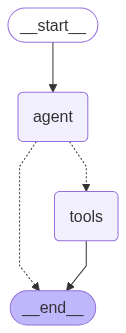

In [140]:
app1

In [141]:
app1.invoke({"messages":["hi how are you?"]})

{'messages': [HumanMessage(content='hi how are you?', additional_kwargs={}, response_metadata={}, id='a18541ac-861c-4bfe-a4dc-57dc5fcbc6d1'),
  AIMessage(content="I'm doing well, thank you for asking!  How are you today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash-latest', 'safety_ratings': []}, id='run--ab3809dd-7c09-4d7b-9d9a-7e504816238f-0', usage_metadata={'input_tokens': 5, 'output_tokens': 18, 'total_tokens': 23, 'input_token_details': {'cache_read': 0}})]}

In [142]:
workflow1.add_edge("tools","agent")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [144]:
app2=workflow1.compile()

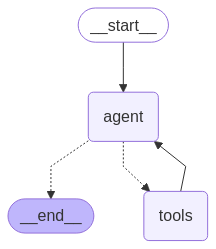

In [145]:
app2

In [147]:
for output in app2.stream({"messages":["what is the weather in sf? or you can say san fransisco in summers"]}):
    for key,value in output.items():
        print(f"here is the output from {key}")
        print("______")
        print(value)
        print("\n")

here is the output from agent
______
{'messages': [AIMessage(content='San Francisco summers are generally mild and comfortable, but can be unpredictable.  Expect daytime highs in the low to mid 60s Fahrenheit (low to mid 18s Celsius), often with a cool breeze, even on sunny days.  Nighttime temperatures typically drop into the 50s Fahrenheit (teens Celsius).  Fog and overcast conditions are common, especially in the mornings and along the coast.  While it rarely gets truly hot, some inland areas might experience warmer temperatures.  So, you should pack layers!', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash-latest', 'safety_ratings': []}, id='run--dc0c1509-2a35-4423-88c3-596ccc4c9270-0', usage_metadata={'input_tokens': 16, 'output_tokens': 108, 'total_tokens': 124, 'input_token_details': {'cache_read': 0}})]}




In [148]:
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

In [149]:
workflow3=StateGraph(MessagesState)

workflow3.add_node("agent",call_model)
workflow3.add_node("tools",tool_node)

workflow3.add_edge(START,"agent")
workflow3.add_conditional_edges("agent",router_function,{"tools":"tools",END:END})
workflow3.add_edge("tools","agent")

In [152]:
app3=workflow3.compile(checkpointer=memory)

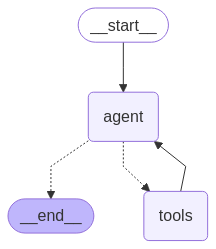

In [153]:
app3

In [154]:
config={"configurable":{"thread_id":"1"}}

In [156]:
events=app3.stream({"messages":["Hi there! My name is Abhishek"]}, config,stream_mode="values")

In [157]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Abhishek
================================== Ai Message ==================================

Hi Abhishek! It's nice to meet you.  How can I help you today?


In [162]:
def chatting(input:str):
    events=app3.stream({"messages":[input]},config,stream_mode="values")
    for event in events:
        event['messages'][-1].pretty_print()


In [163]:
chatting("Hello chat!")

================================ Human Message =================================

Hello chat!
================================== Ai Message ==================================

Hello there! How can I help you today?


In [164]:
chatting("do you know my name?")

================================ Human Message =================================

do you know my name?
================================== Ai Message ==================================

No, I don't know your name.  I have no memory of past conversations.  Each interaction with me starts fresh.  If you'd like to tell me your name, I'd be happy to know it.


nums=[1,2,2,3]

In [168]:
from typing import TypedDict, Optional

class Calcstate(TypedDict):
    input: tuple
    add_result:Optional[float]
    multiply:Optional[float]
    divide:Optional[float]

    

In [169]:
def add(state:Calcstate) -> Calcstate:
    a,b=state['input']
    return {'add_result':a+b}

def multiply(state:Calcstate) -> Calcstate:
    a,b=state["input"]
    return {"multiply":a*b}

def divide(state:Calcstate) -> Calcstate:
    a,b=state["input"]
    try:
        return {"divide":a/b}
    except ZeroDivisionError as e:
        return {"divide":"it is not divisible"}

In [173]:
def router(state: Calcstate) -> str:
    return "add_node" 

In [174]:
graph=StateGraph(Calcstate)

graph.add_node("add_node",add)
graph.add_node("multiply_node",multiply)
graph.add_node("divide_node",divide)

In [175]:
graph.set_entry_point("add_node")
graph.add_edge("add_node","multiply_node")
graph.add_edge("multiply_node","divide_node")
graph.add_edge("divide_node",END)

In [178]:
app=graph.compile()

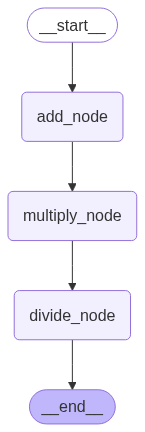

In [179]:
app

In [ ]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Optional, Tuple

class CalcState(TypedDict):
    input: Tuple[float, float]
    add_result: Optional[float]
    multiply_result: Optional[float]
    divide_result: Optional[float]


def starter(state: CalcState) -> CalcState:

    return state

def add(state: CalcState) -> CalcState:
    a, b = state["input"]
    return {"add_result": a + b}

def multiply(state: CalcState) -> CalcState:
    a, b = state["input"]
    return {"multiply_result": a * b}

def divide(state: CalcState) -> CalcState:
    a, b = state["input"]
    return {"divide_result": a / b if b != 0 else None}

def join_results(state: CalcState) -> CalcState:
    return state  


workflow = StateGraph(CalcState)


workflow.add_node("start", starter)
workflow.add_node("add", add)
workflow.add_node("multiply", multiply)
workflow.add_node("divide", divide)
workflow.add_node("join", join_results)


workflow.add_edge("start", "add")
workflow.add_edge("start", "multiply")
workflow.add_edge("start", "divide")


workflow.add_edge("add", "join")
workflow.add_edge("multiply", "join")
workflow.add_edge("divide", "join")


workflow.add_edge("join", END)


workflow.set_entry_point("start")


app = workflow.compile()

result = app.invoke({"input": (10, 2)})
print(result)


{'input': (10, 2), 'add_result': 12, 'multiply_result': 20, 'divide_result': 5.0}


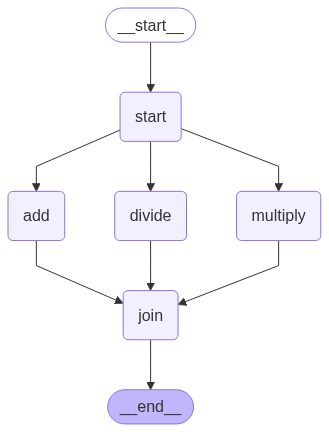

In [183]:
app